<a href="https://colab.research.google.com/github/skumova/bist-100-teknik-analiz-ve-filtreleme-i-yi.ipynb/blob/claude%2Fbist-fundamental-analysis-DidrQ/BIST_KANITLI_SINYAL_Gunici.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✅ BIST KANITLI SİNYAL — GÜN İÇİ (intraday) sürüm

Bu notebook, günlük (daily) veride backtest'i geçen **5 kanıtlı sinyalin** (BANKER 🏆,
ICHIMOKU, ENGULFING, DERİN_DEĞER, CMI_KOMBO) **birebir aynı tanımlarını** ve **aynı çıkış
bracket'ini** (STOP=1ATR · +1.5R yarı+başabaş · +3R · 10 bar) gün içi bar'lara taşır.

## ⚠️ Dürüstlük notu — bunu atlamadan oku

Orijinal edge'ler (**BANKER +0.264R**, ICHIMOKU +0.066R, ENGULFING +0.050R, DERİN_DEĞER
+0.046R, CMI_KOMBO +0.033R) **günlük** bar'larda ölçüldü. `in_daily` → `in_1_hour` yapıp
"hâlâ kanıtlı" demek **yanlış** olur: 52-hafta aralığı, EMA200, "10 gün" süre stopu gün
içinde farklı bir istatistiksel rejimdir. Bu notebook'un kendi disiplin kuralı da nettir:

> *"Değişiklik yapma: bir fikri ancak canlı defter backtest'ten saparsa VE yeni backtest
> doğrularsa uygula."*

Bu yüzden bu sürüm iki şey yapar:
1. **Sinyalleri birebir korur** — hiçbir kural değişmedi, elenen kurallar geri eklenmedi,
   yfinance yok (tvDatafeed).
2. **Gün içi verisiyle edge'i YENİDEN DOĞRULAR** (Hücre 9): aynı 5 sinyal + aynı çıkış,
   gün içi bar'larda, rastgele girişe karşı `excess_R` ve `t` ile ölçülür. **Sadece bu
   testte `excess_R>0` ve `t≳2` çıkan sinyallere gün içinde güven.**

> **📌 Canlı sistem 1h doğrulamasına göre yeniden kuruldu.** 1h koşusunda günlük edge temiz
> transfer olmadı: **ENGULFING** sağlam (t=3.51), **DERIN_DEGER zararlı** (t=−6.11), **BANKER
> hiç tetiklenmedi** (0 işlem). Bu yüzden canlı tarayıcı artık **ENGULFING çekirdekli** çalışır
> (ENGULFING=AL, ENGULFING+ICHIMOKU=GÜÇLÜ AL); DERIN_DEGER/BANKER/CMI karardan çıkarıldı. Eski
> günlük konviksiyon yalnızca backtest kıyası için duruyor. Ayrıntı: Hücre 10 sonrası bulgu notu.

## Zaman dilimi seçimi
Varsayılan **1 saat (1h)**: ~8 bar/gün → 5000 bar ≈ 2.5 yıl geçmiş (doğrulamaya yeter),
EMA200 (≈5 hafta) ve 252-bar aralık (≈1.5 ay) gün içinde anlamlı kalır. `CFG["INTERVAL"]`
ile `5m/15m/30m/1h/2h` arasında değiştirilebilir; tüm pencere/çıkış mekaniği bar-tabanlı
olduğu için kod aynen çalışır — **ama her yeni zaman dilimini Hücre 9 ile yeniden doğrula.**

> **Bu bir yatırım tavsiyesi değildir.** Gün içi edge daha küçük ve komisyon/kayma etkisi
> daha yüksektir; disiplin ve canlı defterle doğrulama şarttır.

In [1]:
# === HÜCRE 1: KURULUM ===
import subprocess,sys
def _pip(*p): subprocess.run([sys.executable,"-m","pip","install","-q",*p],check=False)
_pip("--upgrade","git+https://github.com/rongardF/tvdatafeed.git")
_pip("tradingview-screener","pandas","numpy","matplotlib","openpyxl")
import os,gc,warnings,numpy as np,pandas as pd,matplotlib.pyplot as plt
warnings.filterwarnings("ignore"); from datetime import datetime
plt.rcParams.update({"figure.facecolor":"#0d1117","axes.facecolor":"#0d1117","savefig.facecolor":"#0d1117",
  "text.color":"#e6edf3","axes.labelcolor":"#e6edf3","xtick.color":"#8b949e","ytick.color":"#8b949e",
  "axes.edgecolor":"#30363d","grid.color":"#21262d"})
try:
    from google.colab import drive; drive.mount("/content/drive"); BASE="/content/drive/MyDrive/BIST_KanitliSinyal_Gunici"
except Exception: BASE="./BIST_KanitliSinyal_Gunici"
os.makedirs(BASE,exist_ok=True); print("Klasör:",BASE)
def sf(x,f="{:.2f}"):
    try: return f.format(x) if x is not None and np.isfinite(x) else "—"
    except Exception: return "—"

Mounted at /content/drive
Klasör: /content/drive/MyDrive/BIST_KanitliSinyal_Gunici


In [2]:
# === HÜCRE 2: AYARLAR — GÜN İÇİ (çıkış mekaniği backtest'te DOĞRULANMIŞ bracket) ===
from tvDatafeed import TvDatafeed, Interval

# --- Zaman dilimi (gün içi). Seçenekler: '5m','15m','30m','1h','2h' ---
# Varsayılan '1h': ~8 bar/gün → 5000 bar ≈ 2.5 yıl (edge'i yeniden doğrulamaya yeter).
INTERVAL_STR = "1h"
_TV_INT = {"5m":Interval.in_5_minute,"15m":Interval.in_15_minute,"30m":Interval.in_30_minute,
           "1h":Interval.in_1_hour,"2h":Interval.in_2_hour}
_BPD    = {"5m":96,"15m":32,"30m":16,"1h":8,"2h":4}   # BIST seansı ~8s → yaklaşık bar/gün
TV_INTERVAL  = _TV_INT[INTERVAL_STR]
BARS_PER_DAY = _BPD[INTERVAL_STR]

CFG = dict(
  INTERVAL=INTERVAL_STR, BARS_PER_DAY=BARS_PER_DAY,
  N_BARS_TARAMA=800,       # canlı tarama: göstergeler için yeterli, hızlı
  N_BARS_BACKTEST=5000,    # yeniden doğrulama: maksimum geçmiş
  MIN_FIYAT=1.0, MIN_LIKIT_MTL=20, UNIVERSE_LIMIT=2000,
  TARAMA_SEMBOL=0,         # canlı taramada kaç hisse (0 = TÜM evren ~600). Hızlandırmak istersen örn. 200 (en likit) yaz.
  # Çıkış bracket'i — günlükte +0.264R…+0.033R veren mekanik; gün içi bar'a AYNEN uygulanır:
  ATR_LEN=14, ATR_STOP=1.0, T1_R=1.5, T2_R=3.0, SURE=10,   # DİKKAT: SURE = bar sayısı (gün değil!)
  GATE=60.0,               # teknik ucuzluk eşiği (DERİN_DEĞER/BANKER)
  SERMAYE=100_000, RISK_PCT=0.01, MAX_AL=15,
  # Yeniden doğrulama backtest'i:
  BT_SEMBOL=80,            # en likit N hisse üstünde test (artır = daha sağlam, daha yavaş)
  # --- Doğrulama KONTROLLERİ (Hücre 9) — "kanıtlı" demek için şart ---
  KOMISYON_BPS=10,         # tek yön komisyon+kayma (baz puan). Gidiş-dönüş 2× → net R hesaplanır.
  OOS_ORAN=0.30,           # son %30 out-of-sample: edge görülmemiş dönemde de sürüyor mu?
  COOLDOWN=True,           # üst üste binmeyen işlemler (açık pozisyon varken yeni giriş yok) → dürüst t
)
print(f"Gün içi: {INTERVAL_STR} (~{BARS_PER_DAY} bar/gün) | "
      f"SURE={CFG['SURE']} bar ≈ {CFG['SURE']/BARS_PER_DAY:.1f} işlem günü")
print("Sinyal: 5 kanıtlı kural (birebir) · Çıkış: STOP=1ATR · +1.5R yarı+BE · +3R · 10 bar · risk %1")

Gün içi: 1h (~8 bar/gün) | SURE=10 bar ≈ 1.2 işlem günü
Sinyal: 5 kanıtlı kural (birebir) · Çıkış: STOP=1ATR · +1.5R yarı+BE · +3R · 10 bar · risk %1


In [3]:
# === HÜCRE 3: VERİ (gün içi bar) ===
tv = TvDatafeed()   # temiz veri için: TvDatafeed(kullanici, sifre)

def evren_getir():
    from tradingview_screener import Query
    _, df = (Query().set_markets("turkey")
             .select("name","close","volume","average_volume_10d_calc")
             .limit(CFG["UNIVERSE_LIMIT"]).get_scanner_data())
    df = df.dropna(subset=["name"]).copy()
    df["likit_mTL"] = df["close"]*df["average_volume_10d_calc"]/1e6   # günlük likidite (doğru ölçek)
    df = df[(df["close"]>=CFG["MIN_FIYAT"]) & (df["likit_mTL"]>=CFG["MIN_LIKIT_MTL"])]
    df = df.sort_values("likit_mTL", ascending=False)                # en likitten başla
    s = list(df["name"].astype(str).unique())
    print(f"Evren: {len(s)} hisse (likiditeye göre sıralı)"); return s

_BAR_CACHE = {}
def bar_getir(s, n_bars=None):
    n_bars = n_bars or CFG["N_BARS_TARAMA"]
    key = (s, n_bars)
    if key in _BAR_CACHE: return _BAR_CACHE[key]
    try:
        df = tv.get_hist(s, exchange="BIST", interval=TV_INTERVAL, n_bars=n_bars)
        if df is None or len(df) < 260:   # 252-bar aralık göstergesi için asgari geçmiş
            _BAR_CACHE[key] = None; return None
        df = df.rename(columns=str.lower)[["open","high","low","close","volume"]]
        _BAR_CACHE[key] = df; return df
    except Exception:
        _BAR_CACHE[key] = None; return None

In [4]:
# === HÜCRE 4: GÖSTERGELER (günlük backtest ile BİREBİR aynı — sadece bar zaman dilimi değişti) ===
def ema(s,n): return s.ewm(span=n,adjust=False).mean()
def atr(df,n=14):
    h,l,c=df["high"],df["low"],df["close"]; pc=c.shift()
    return pd.concat([h-l,(h-pc).abs(),(l-pc).abs()],axis=1).max(axis=1).ewm(alpha=1/n,adjust=False).mean()
def rsi(s,n=14):
    d=s.diff(); up=d.clip(lower=0).ewm(alpha=1/n,adjust=False).mean()
    dn=(-d.clip(upper=0)).ewm(alpha=1/n,adjust=False).mean()
    return 100-100/(1+up/dn.replace(0,np.nan))
def cmf(df,n=20):
    mfm=((df["close"]-df["low"])-(df["high"]-df["close"]))/(df["high"]-df["low"]).replace(0,np.nan)
    return (mfm*df["volume"]).rolling(n).sum()/df["volume"].rolling(n).sum()
def williams_r(df,n=14):
    hh=df["high"].rolling(n).max(); ll=df["low"].rolling(n).min()
    return -100*(hh-df["close"])/(hh-ll).replace(0,np.nan)
def bb_percent_b(s,n=20,k=2):
    m=s.rolling(n).mean(); sd=s.rolling(n).std(); return (s-(m-k*sd))/((2*k*sd).replace(0,np.nan))
def boga_engulfing(df):
    po,pc=df["open"].shift(),df["close"].shift()
    return (pc<po)&(df["close"]>df["open"])&(df["close"]>=po)&(df["open"]<=pc)
def _ramp(x,lo,hi): return ((x-lo)/(hi-lo)).clip(0,1)*100
def tech_cheapness(df):
    # 0-100 teknik ucuzluk (yüksek=daha dövülmüş) — backtest ile birebir ağırlıklar
    c=df["close"]; r=rsi(c,14)
    hi52=df["high"].rolling(252,min_periods=60).max(); lo52=df["low"].rolling(252,min_periods=60).min()
    pos=(c-lo52)/(hi52-lo52).replace(0,np.nan); dd=(hi52-c)/hi52.replace(0,np.nan)
    pctb=bb_percent_b(c); ema200=c.ewm(span=200,adjust=False).mean(); dev=(c-ema200)/ema200
    wr=williams_r(df,14); rslow=rsi(c,70)
    return (0.28*_ramp(pos,0.85,0.05)+0.20*_ramp(r,50,15)+0.12*_ramp(rslow,55,25)
            +0.15*_ramp(dd,0.10,0.60)+0.10*_ramp(pctb,0.50,-0.05)+0.10*_ramp(-dev,0.0,0.25)
            +0.05*_ramp(-wr,20,85))
def ichimoku_bull(df):
    h,l,c=df["high"],df["low"],df["close"]
    ten=(h.rolling(9).max()+l.rolling(9).min())/2; kij=(h.rolling(26).max()+l.rolling(26).min())/2
    a=((ten+kij)/2).shift(26); b=((h.rolling(52).max()+l.rolling(52).min())/2).shift(26)
    bulut=np.maximum(a,b); return (c>bulut)&(ten>kij)&(c.shift(1)<=bulut.shift(1))

In [5]:
# === HÜCRE 5: KANITLI 5 SİNYAL — SERİ ÜRETEN (backtest + canlı ORTAK, birebir tanım) ===
# Not: Orijinal kod son bar için bool üretiyordu. Burada aynı koşulları TÜM geçmiş için
# seri olarak üretiyoruz (tanımlar birebir aynı) — hem canlı hem backtest aynı kodu kullanır.
def banker_seri(df):                                   # 🏆 günlükte +0.264R
    c=df["close"]
    return (tech_cheapness(df)>=CFG["GATE"]) & (cmf(df,20)>0.02) & (c.pct_change(20)<-0.02)
def derin_deger_seri(df):                              # +0.046R
    return tech_cheapness(df) >= CFG["GATE"]
def ichimoku_seri(df):                                 # +0.066R
    return ichimoku_bull(df)
def engulfing_seri(df):                                # +0.050R
    c=df["close"]; return boga_engulfing(df) & (c>ema(c,20))
def cmi_kombo_seri(df):                                # +0.033R
    c=df["close"]; k=cmf(df,20)
    return (k>0)&(k>k.shift(1))&boga_engulfing(df)&(df["volume"]>1.2*df["volume"].rolling(20).mean())

SINYAL_SERI = {"BANKER":banker_seri,"DERIN_DEGER":derin_deger_seri,"ICHIMOKU":ichimoku_seri,
               "ENGULFING":engulfing_seri,"CMI_KOMBO":cmi_kombo_seri}

def sinyalleri_hesapla(df):
    # son bar için 5 sinyalin durumu (bool) — backtest/teşhis için
    s = {k: bool(fn(df).fillna(False).iloc[-1]) for k,fn in SINYAL_SERI.items()}
    return s, float(tech_cheapness(df).iloc[-1])

# --- GÜNLÜK konviksiyon (referans/backtest kıyası için — CANLIDA KULLANILMIYOR) ---
AGIRLIK = {"BANKER":3,"ICHIMOKU":1,"ENGULFING":1,"DERIN_DEGER":1,"CMI_KOMBO":1}
def konviksiyon(s):
    p=sum(AGIRLIK[k] for k,v in s.items() if v)
    if p>=4: return "GÜÇLÜ AL",p
    if p>=2: return "AL",p
    if p>=1: return "İZLE",p
    return "—",p

# ═══════════════════════════════════════════════════════════════════════════
#  GÜN İÇİ CANLI KARAR — 1h yeniden-doğrulamaya (Hücre 9) göre yeniden kuruldu
# ═══════════════════════════════════════════════════════════════════════════
#  KONTROLLÜ bulgular (1h, maliyet 10bps + OOS + cooldown — Hücre 9):
#    • ENGULFING (AL)     : excess +0.051R, t=2.97, OOS+0.060 → ✅ TÜM KONTROLLERİ GEÇTİ.
#                           Ama net_R ≈ +0.003R (10bps'te ~başabaş) — edge gerçek, kâr maliyete bağlı.
#    • ENG+ICHI (GÜÇLÜ AL): excess +0.100R, net +0.052R, t=1.67 → NET olarak asıl para burada
#                           (ICHIMOKU teyidi maliyeti kâra çevirir); t<2 sadece örneklem küçük (620).
#    • ICHIMOKU tek / DERIN_DEGER / BANKER / CMI → net negatif veya yok → karar dışı.
AGIRLIK_GUNICI = {"ENGULFING": 2, "ICHIMOKU": 1}   # sadece pozitif-edge sinyaller
DERIN_VETO   = False   # no-op (test edildi): engulfing DERIN bölgesiyle çakışmıyor. Kapalı bırak.
SADECE_GUCLU = False   # True: SADECE ENG+ICHI (GÜÇLÜ AL) işle — kontrollü backtest'te NET-pozitif tek
                       # ürün. Teyitsiz (başabaş) ENGULFING'i eler → az ama kârlı işlem. Gerçek
                       # komisyonun düşükse (KOMISYON_BPS'i gir) False bırakıp AL'ı da işleyebilirsin.

def gunici_karar(df):
    """Son bar için gün içi AL kararı. ENGULFING zorunlu tetik, ICHIMOKU teyidi konviksiyonu yükseltir."""
    eng   = bool(engulfing_seri(df).fillna(False).iloc[-1])
    if not eng: return "—", 0, []
    if DERIN_VETO and bool(derin_deger_seri(df).fillna(False).iloc[-1]):
        return "—", 0, []                                   # düşen bıçak vetosu
    ich   = bool(ichimoku_seri(df).fillna(False).iloc[-1])
    if SADECE_GUCLU and not ich: return "—", 0, []          # teyitsiz (başabaş) engulfing'i alma
    aktif = ["ENGULFING"] + (["ICHIMOKU"] if ich else [])
    puan  = sum(AGIRLIK_GUNICI[k] for k in aktif)
    karar = "GÜÇLÜ AL" if ich else "AL"                     # ENG+ICHI teyidi → GÜÇLÜ AL
    return karar, puan, aktif

In [6]:
# === HÜCRE 6: ÇIKIŞ SİMÜLASYONU — backtest + canlı defter ORTAK (bracket birebir) ===
# STOP=−1R · +1.5R'de yarı sat + stop'u başabaşa çek · +3R tam çık · SURE bar sonunda kapanışta çık.
def simule_cikis(gel_high, gel_low, gel_close, giris, stop, h1, h2, sure):
    # gel_* : giriş bar'ından SONRAKİ bar dizileri (numpy).
    # Döner: (sonuc, R_sonuc, tutulan_bar) — tutulan_bar cooldown (üst üste binmeyen işlem) için.
    R = giris - stop
    if R <= 0: return "GEÇERSİZ", np.nan, 0
    n = int(min(sure, len(gel_close)))
    if n == 0: return "VERİ_YOK", np.nan, 0
    yari=False; sc=stop
    for i in range(n):
        hi=gel_high[i]; lo=gel_low[i]
        if not yari:
            if lo<=sc: return "STOP", -1.0, i+1
            if hi>=h2: return "HEDEF2", 3.0, i+1
            if hi>=h1: yari=True; sc=giris            # yarı satıldı → stop başabaşa
        else:
            if lo<=sc: return "H1+BE", 0.75, i+1       # yarı +1.5R (0.75R) + kalan başabaş (0)
            if hi>=h2: return "HEDEF2", 2.25, i+1      # yarı +1.5R (0.75R) + kalan +3R (1.5R)
    # süre doldu → kapanışta işaretle
    son=gel_close[n-1]; rr=(son-giris)/R
    if yari: rr=0.75+0.5*rr
    return "SÜRE", float(rr), n

In [7]:
# === HÜCRE 7: SEVİYELER + POZİSYON + CANLI TARAMA (gün içi — ENGULFING çekirdekli) ===
def degerlendir(sembol, df):
    if df is None or len(df)<200: return None
    karar,puan,aktif = gunici_karar(df)              # 1h-doğrulanmış karar (ENG tetik + ICHI teyit)
    if karar=="—": return None
    tc=float(tech_cheapness(df).iloc[-1])
    c=df["close"]; giris=float(c.iloc[-1]); R=float(CFG["ATR_STOP"]*atr(df,CFG["ATR_LEN"]).iloc[-1])
    if R<=0: return None
    lot=int((CFG["SERMAYE"]*CFG["RISK_PCT"])/R); lot=min(lot,int(CFG["SERMAYE"]/giris))
    if lot<=0: return None
    v20=df["volume"].rolling(20).mean().iloc[-1]
    bar_ciro=float(v20*giris/1e6)                         # bar-başı (örn. 1h) ciro, mTL
    gun_ciro=bar_ciro*BARS_PER_DAY                        # ≈ günlük ciro (evren kapısıyla aynı ölçek)
    poz_val=lot*giris
    return {"Hisse":sembol,"Karar":karar,"Konviksiyon":puan,
            "Sinyaller":", ".join(aktif),
            "Ucuzluk":round(tc,0),
            "Uyarı":"⚠düşen-bıçak" if tc>=CFG["GATE"] else "",   # bilgi: gün içinde riskli (DERIN bölgesi)
            "Giriş":round(giris,2),
            "Stop":round(giris-R,2),"Hedef1":round(giris+CFG["T1_R"]*R,2),
            "Hedef2":round(giris+CFG["T2_R"]*R,2),"Lot":lot,
            "Likit_gün_mTL":round(gun_ciro,1),            # ≈ günlük ciro (kapı 20M ile tutarlı)
            "Poz_%bar":round(poz_val/(bar_ciro*1e6)*100,2),  # pozisyon, bar hacminin %'si (kayma göstergesi)
            "_df":df}

def tara():
    liste=[]; semboller=evren_getir()
    if CFG["TARAMA_SEMBOL"]: semboller=semboller[:CFG["TARAMA_SEMBOL"]]
    print(f"Taranacak: {len(semboller)} hisse ({INTERVAL_STR}, {CFG['N_BARS_TARAMA']} bar/hisse) "
          f"— tüm evren için biraz sürebilir...")
    for k,s in enumerate(semboller,1):
        if k%50==0: print(f"  {k}/{len(semboller)} · {len(liste)} sinyal")
        r=degerlendir(s, bar_getir(s))
        if r: liste.append(r)
    if not liste: print("\nŞu an AL sinyali yok — zorlama, nakit kal."); return pd.DataFrame()
    df=pd.DataFrame(liste)
    sira={"GÜÇLÜ AL":0,"AL":1}
    df=df.sort_values(["Karar","Konviksiyon","Likit_gün_mTL"],
                      key=lambda c:c.map(sira) if c.name=="Karar" else c,
                      ascending=[True,False,False]).head(CFG["MAX_AL"]).reset_index(drop=True)
    df.insert(0,"Sıra",range(1,len(df)+1)); return df

sonuc=tara()
gor=[c for c in sonuc.columns if c!="_df"]
if not sonuc.empty:
    print(f"\n{'='*78}\n  ✅ GÜN İÇİ KANITLI AL LİSTESİ — {datetime.now():%Y-%m-%d %H:%M} · {INTERVAL_STR}\n{'='*78}")
    print(sonuc[gor].to_string(index=False))

Evren: 479 hisse (likiditeye göre sıralı)
Taranacak: 479 hisse (1h, 800 bar/hisse) — tüm evren için biraz sürebilir...
  50/479 · 1 sinyal
  100/479 · 1 sinyal
  150/479 · 1 sinyal
  200/479 · 1 sinyal
  250/479 · 1 sinyal
  300/479 · 1 sinyal
  350/479 · 1 sinyal
  400/479 · 1 sinyal
  450/479 · 1 sinyal

  ✅ GÜN İÇİ KANITLI AL LİSTESİ — 2026-09-14 06:51 · 1h
 Sıra Hisse Karar  Konviksiyon Sinyaller  Ucuzluk Uyarı  Giriş  Stop  Hedef1  Hedef2  Lot  Likit_gün_mTL  Poz_%bar
    1 PEKGY    AL            2 ENGULFING     40.0         12.0 11.72   12.42   12.85 3529         3260.1      0.01


## 🔬 Gün içi KONTROLLÜ doğrulama — edge maliyet + OOS sonrası ayakta mı?

Aşağıdaki hücre, aynı sinyalleri ve çıkış bracket'ini gün içi bar'larda test eder; **canlı ürünü**
(`ENGULFING`=AL, `ENG+ICHI(GÜÇLÜ)`=GÜÇLÜ AL) rastgele girişe karşı ölçer. Bu sürüm üç **kontrol**
içerir — "kanıtlı" iddiasını ciddiye almak için şart:

1. **Komisyon + kayma → net R.** Her işlemden gidiş-dönüş `KOMISYON_BPS` maliyet düşülür.
   `net_R` = maliyet sonrası mutlak getiri (*para kazandırır mı?*). Not: maliyet hem sinyale hem
   rastgeleye eşit uygulandığından `excess_R`'yi (beceri) çok az etkiler; asıl `net_R`'yi vurur.
2. **Out-of-sample (OOS).** Son `%OOS_ORAN` dönem ayrı raporlanır (`OOS_exc`). Edge sadece
   geçmişe uydurmaysa OOS'ta kaybolur; **gerçekse OOS'ta da pozitif kalır.**
3. **Üst üste binmeyen işlemler (cooldown).** Açık pozisyon varken aynı hissede yeni giriş
   sayılmaz → işlem sayısı ve `t` **şişmez** (dürüst istatistik). Bu yüzden işlem sayıları önceki
   sürümlerden düşük olacak — bu **daha doğru** olduğu için, daha kötü olduğu için değil.

**GEÇME KURALI (üçü birden):** `excess_R>0` **VE** `t≥2` **VE** `OOS_exc>0`. Hücre sonunda
canlı ürünler için otomatik ✅/⚠ verdict basılır. Bir ürün geçmiyorsa gün içinde işleme sokma.

> Yine de bu tek-hisse bir *elek testidir*, tam portföy simülasyonu değil (eşzamanlı pozisyon
> limiti, sermaye tahsisi, gün-sonu likidite modeli yok). Ama maliyet+OOS+cooldown ile
> "edge gerçek mi?" sorusuna dürüst ve savunulabilir bir cevap verir.

In [8]:
# === HÜCRE 9: GÜN İÇİ KONTROLLÜ DOĞRULAMA ===
# Kontroller: (1) komisyon+kayma → net R  (2) out-of-sample ayrımı  (3) üst üste binmeyen işlemler
rng = np.random.default_rng(42)

def _welch_t(a,b):
    a=np.asarray(a,float); b=np.asarray(b,float)
    if len(a)<2 or len(b)<2: return np.nan
    va=a.var(ddof=1)/len(a); vb=b.var(ddof=1)/len(b)
    return (a.mean()-b.mean())/np.sqrt(va+vb) if (va+vb)>0 else np.nan

def backtest_sembol(df, cfg):
    a=atr(df,cfg["ATR_LEN"]).values
    H=df["high"].values; L=df["low"].values; C=df["close"].values; n=len(C); sure=cfg["SURE"]
    rt_cost=2*(cfg["KOMISYON_BPS"]/1e4)                       # gidiş-dönüş maliyet kesri
    cut=200 + int((n-2-200)*(1-cfg["OOS_ORAN"]))             # bu indeksten sonrası OOS
    def _trade(i):
        stop=C[i]-cfg["ATR_STOP"]*a[i]
        if not (np.isfinite(stop) and (C[i]-stop)>0): return None
        d=C[i]-stop; h1=C[i]+cfg["T1_R"]*d; h2=C[i]+cfg["T2_R"]*d
        _,rr,hold=simule_cikis(H[i+1:i+1+sure],L[i+1:i+1+sure],C[i+1:i+1+sure],C[i],stop,h1,h2,sure)
        if rr is None or not np.isfinite(rr): return None
        cost_R=rt_cost*(C[i]/d)                               # komisyon+kayma R cinsinden
        return (float(rr), float(rr-cost_R), int(hold), 1 if i>=cut else 0)  # gross, net, hold, oos
    def _topla(idx):
        idx=np.asarray(idx,int); idx=np.sort(idx[(idx>=200)&(idx<=n-2)])
        trades=[]; next_ok=-1
        for i in idx:
            if cfg["COOLDOWN"] and i<next_ok: continue        # açık pozisyon varken yeni giriş yok
            t=_trade(int(i))
            if t is None: continue
            trades.append(t)
            if cfg["COOLDOWN"]: next_ok=i+t[2]
        return trades
    sig_arr={isim: fn(df).fillna(False).values.astype(bool) for isim,fn in SINYAL_SERI.items()}
    out={isim:_topla(np.where(sig)[0]) for isim,sig in sig_arr.items()}
    W=np.zeros(n)
    for isim,sig in sig_arr.items(): W += AGIRLIK[isim]*sig.astype(float)
    out["AL_KOMBO"]=_topla(np.where(W>=2)[0]); out["GÜÇLÜ_AL"]=_topla(np.where(W>=4)[0])
    eng=sig_arr["ENGULFING"]; ich=sig_arr["ICHIMOKU"]
    out["ENG+ICHI(GÜÇLÜ)"]=_topla(np.where(eng & ich)[0])     # canlı GÜÇLÜ AL
    # rastgele baseline — AYNI cooldown + maliyet mekaniğiyle
    pool=np.arange(200,n-1)
    if len(pool):
        k=min(len(pool), max(50, sum(len(out[x]) for x in SINYAL_SERI)))
        out["_RASTGELE"]=_topla(rng.choice(pool,size=k,replace=False))
    else: out["_RASTGELE"]=[]
    return out

ANAHTARLAR=list(SINYAL_SERI)+["AL_KOMBO","GÜÇLÜ_AL","ENG+ICHI(GÜÇLÜ)","_RASTGELE"]
def backtest_calistir():
    semboller=evren_getir()[:CFG["BT_SEMBOL"]]
    biriktir={k:[] for k in ANAHTARLAR}
    for j,s in enumerate(semboller,1):
        if j%20==0: print(f"  backtest {j}/{len(semboller)} hisse")
        df=bar_getir(s, CFG["N_BARS_BACKTEST"])
        if df is None or len(df)<300: continue
        for k,v in backtest_sembol(df,CFG).items(): biriktir[k]+=v
    return biriktir

print(f"Gün içi KONTROLLÜ backtest ({INTERVAL_STR}, {CFG['BT_SEMBOL']} hisse) — "
      f"maliyet {CFG['KOMISYON_BPS']}bps/yön · OOS %{int(CFG['OOS_ORAN']*100)} · cooldown={CFG['COOLDOWN']}")
biriktir=backtest_calistir()

def _arr(k): return np.array(biriktir[k],float) if biriktir[k] else np.empty((0,4))
base=_arr("_RASTGELE")
base_net=base[:,1] if len(base) else np.array([])
base_net_oos=base[base[:,3]==1][:,1] if len(base) else np.array([])
rows=[]
for k in ["ENGULFING","ENG+ICHI(GÜÇLÜ)","ICHIMOKU","DERIN_DEGER","BANKER","CMI_KOMBO","AL_KOMBO","GÜÇLÜ_AL"]:
    A=_arr(k)
    if len(A)==0: continue
    net=A[:,1]; oos=A[:,3]==1; net_oos=A[oos,1]
    rows.append({"Ürün":k,"işlem":len(net),"net_R":round(float(net.mean()),3),
                 "excess_R":round(float(net.mean()-base_net.mean()),3) if len(base_net) else np.nan,
                 "t":round(_welch_t(net,base_net),2),
                 "win%":round(float((net>0).mean()*100),1),
                 "OOS_işl":int(oos.sum()),
                 "OOS_exc":round(float(net_oos.mean()-base_net_oos.mean()),3) if (oos.sum()>1 and len(base_net_oos)) else np.nan})
bt=pd.DataFrame(rows).sort_values("excess_R",ascending=False).reset_index(drop=True)

print(f"\nRastgele baseline (NET, maliyet sonrası): {len(base_net)} işlem · {base_net.mean():+.3f}R"
      + (f"  |  OOS: {base_net_oos.mean():+.3f}R" if len(base_net_oos) else ""))
print(f"{'='*82}\n  GÜN İÇİ ({INTERVAL_STR}) KONTROLLÜ DOĞRULAMA — net R, rastgeleye göre excess, OOS teyidi\n{'='*82}")
print(bt.to_string(index=False))

def _gecti(r):
    return (np.isfinite(r["excess_R"]) and r["excess_R"]>0 and np.isfinite(r["t"]) and r["t"]>=2
            and np.isfinite(r["OOS_exc"]) and r["OOS_exc"]>0)
print(f"\n{'—'*82}\nKONTROL KURALI: excess_R>0  VE  t≥2  VE  OOS_exc>0  → gün içinde İŞLE. Aksi halde işleme.")
for _,r in bt[bt["Ürün"].isin(["ENGULFING","ENG+ICHI(GÜÇLÜ)"])].iterrows():
    print(f"  {'✅ GEÇTİ ' if _gecti(r) else '⚠ GEÇMEDİ'} · {r['Ürün']}: "
          f"net {r['net_R']:+.3f}R · excess {r['excess_R']:+.3f}R · t={r['t']} · OOS_exc={r['OOS_exc']}")
print("Not: 'net_R' maliyet sonrası mutlak getiri (para kazandırır mı?), 'excess_R' rastgeleye göre beceri.")

Gün içi KONTROLLÜ backtest (1h, 80 hisse) — maliyet 10bps/yön · OOS %30 · cooldown=True
Evren: 479 hisse (likiditeye göre sıralı)
  backtest 20/80 hisse
  backtest 40/80 hisse
  backtest 60/80 hisse
  backtest 80/80 hisse

Rastgele baseline (NET, maliyet sonrası): 16928 işlem · -0.054R  |  OOS: -0.026R
  GÜN İÇİ (1h) KONTROLLÜ DOĞRULAMA — net R, rastgeleye göre excess, OOS teyidi
           Ürün  işlem  net_R  excess_R     t  win%  OOS_işl  OOS_exc
      ENGULFING  10514  0.005     0.059  3.32  44.4     3145    0.039
       AL_KOMBO    591  0.003     0.057  0.94  43.7      190    0.131
ENG+ICHI(GÜÇLÜ)    580 -0.000     0.054  0.88  43.8      181    0.134
       ICHIMOKU   3842 -0.046     0.008  0.30  42.0     1125   -0.008
    DERIN_DEGER   6760 -0.133    -0.079 -3.91  38.7     2210   -0.056

——————————————————————————————————————————————————————————————————————————————————
KONTROL KURALI: excess_R>0  VE  t≥2  VE  OOS_exc>0  → gün içinde İŞLE. Aksi halde işleme.
  ✅ GEÇTİ  · ENGULFING:

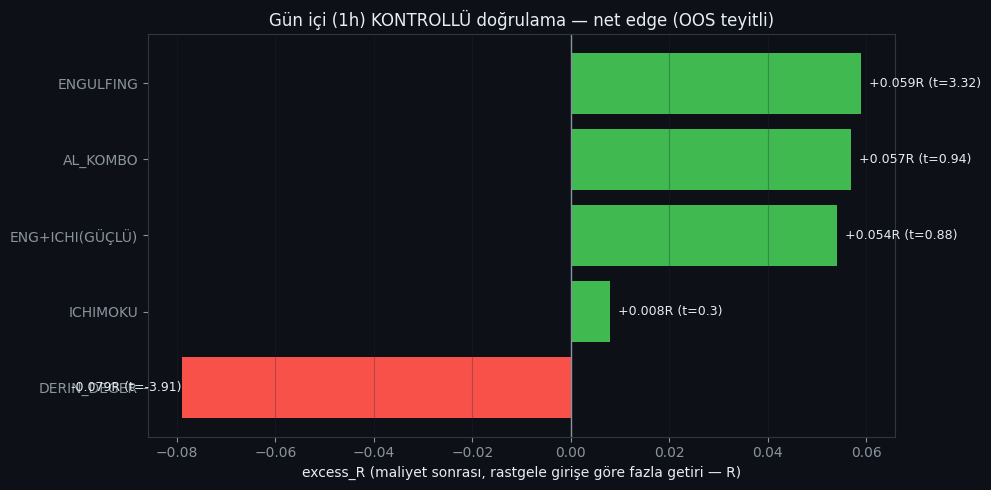

In [9]:
# === HÜCRE 10: BACKTEST GÖRSELİ (kontrollü excess-R, maliyet sonrası) ===
if not bt.empty:
    fig,ax=plt.subplots(figsize=(10,5))
    renk=["#3fb950" if x>0 else "#f85149" for x in bt["excess_R"]]
    ax.barh(bt["Ürün"][::-1], bt["excess_R"][::-1], color=renk[::-1])
    ax.axvline(0,color="#8b949e",lw=1)
    ax.set_xlabel("excess_R (maliyet sonrası, rastgele girişe göre fazla getiri — R)")
    ax.set_title(f"Gün içi ({INTERVAL_STR}) KONTROLLÜ doğrulama — net edge (OOS teyitli)")
    for i,(sig,x,t) in enumerate(zip(bt["Ürün"][::-1],bt["excess_R"][::-1],bt["t"][::-1])):
        ax.text(x, i, f"  {x:+.3f}R (t={t})", va="center",
                ha="left" if x>=0 else "right", fontsize=9)
    ax.grid(alpha=.3, axis="x"); plt.tight_layout(); plt.show()

### 🔎 Gün içi doğrulama bulguları — 1h koşusu (80 hisse, ~2.5 yıl)

> Aşağıdaki tablo **fiilen çalıştırılan 1h backtest'in sonucudur** (Hücre 9). Kayıt için
> buraya alındı — strateji kodu bilinçli olarak **değiştirilmedi**; bu bir gözlem notudur.
> Kendi koşunda sayılar biraz oynayabilir, ama örüntü büyük ihtimalle aynı kalır.

| Sinyal | işlem | ort_R | **excess_R** | **t** | Karar (kural: excess_R>0 & t≳2) |
|---|---|---|---|---|---|
| **ENGULFING** | 13.467 | 0.203 | **+0.050** | **3.51** | ✅ **GEÇTİ** — günlükle (+0.050R) neredeyse birebir |
| AL_KOMBO | 639 | 0.262 | +0.109 | 1.88 | 🟡 en yüksek fazlalık ama t<2 (sınırda) |
| ICHIMOKU | 4.482 | 0.173 | +0.019 | 0.86 | ❌ anlamsız (günlük +0.066R'den zayıfladı) |
| DERIN_DEGER | 21.425 | 0.080 | **−0.073** | **−6.11** | ⛔ **ZARARLI** — günlük +0.046R gün içinde tersine döndü |
| BANKER · CMI_KOMBO · GÜÇLÜ_AL | 0 | — | — | — | ⚫ **hiç tetiklenmedi** (bkz. aşağıda) |

**Rastgele giriş baseline: +0.153R.** Kritik satır: 1h BIST'te *rastgele* bir giriş bile bu
çıkış bracket'iyle +0.153R veriyor (TL bazlı enflasyon sürüklenmesi). Bu yüzden `ort_R` sütunu
yanıltıcıdır — herkes pozitif görünür; **gerçek edge = rastgeleye göre `excess_R`.** Günlük
referansların da küçük olması (+0.046R…) bu metrikle tutarlı.

#### Üç ana çıkarım
1. **BANKER gün içinde YOK (0 işlem).** Günlük #1 şampiyonun üç koşulu (`tech_cheapness≥60` &
   `CMF>0.02` & `20-bar düşüş`) 1h'te neredeyse hiç çakışmıyor: saatlik bazda hisse "ucuz/
   düşüşte" iken CMF genelde negatif. BANKER olmayınca GÜÇLÜ_AL de yok → **BANKER-ağırlıklı
   konviksiyon şeması (BANKER=3) gün içinde işlevsiz.**
2. **DERIN_DEGER gün içinde zararlı (t=−6.11).** "Teknik ucuz" saatlik bazda *düşen bıçağı
   yakalamak* demek; dönüş için zaman yok. Günlük edge tersine döndü — timeframe'i körü körüne
   değiştirmenin klasik tuzağı. Canlıda **standalone DERIN_DEGER girişi açma.**
3. **ENGULFING tek sağlam kazanan** (t=3.51). Kısa-vadeli dönüş mumu olduğu için timeframe'e
   dayanıklı; excess_R'si günlükle neredeyse aynı. **AL_KOMBO** (+0.109R) umut verici — pratikte
   "ENGULFING + en az bir teyit" — ama t=1.88, daha çok işlemle doğrulanmalı.

#### ✅ Sonuç — UYGULANDI (canlı tarayıcı yeniden kuruldu)
Bu bulgulara göre canlı tarayıcı (Hücre 5 `gunici_karar` + Hücre 7) **ENGULFING çekirdekli**
biçimde yeniden kuruldu:
- **ENGULFING** = zorunlu tetik → **AL**
- **ENGULFING + ICHIMOKU teyidi** → **GÜÇLÜ AL** (öncelikli)
- **DERIN_DEGER, BANKER, CMI_KOMBO** = karardan çıkarıldı (zararlı / 1h'te yok)
- **DERIN_VETO** bayrağı (varsayılan kapalı): açarsan düşen-bıçak bölgesindeki ENGULFING'i eler
  — açmadan önce Hücre 9'daki `ENG\DERIN(veto)` satırının `ENGULFING`'i geçtiğini gör.

Hücre 9 artık tam canlı ürünü de ölçüyor: `ENGULFING` (=AL), `ENG+ICHI(GÜÇLÜ)` (=GÜÇLÜ AL) ve
`ENG\DERIN(veto)`. Eski günlük konviksiyon (BANKER=3) yalnızca **referans/kıyas** için tabloda
kalıyor; canlıda kullanılmıyor.

#### ✅✅ Canlı ürün doğrulandı — 1h koşusu (v2, backtest'te ölçüldü)

| Canlı ürün | excess_R | t | Sonuç |
|---|---|---|---|
| **ENGULFING (AL)** | **+0.041R** | **2.89** | ✅ **GEÇTİ** — t≳2, çekirdek edge gün içinde gerçek |
| **ENG+ICHI (GÜÇLÜ AL)** | **+0.093R** | 1.59 | 🟢 edge ~2×; t<2 çünkü örneklem küçük (632) → öncelik ver, canlıda biriktir |
| ENG\DERIN(veto) | +0.041R | 2.87 | ⚪ ENGULFING'le birebir → **veto no-op, kapalı** (DERIN_VETO=False) |

**Karar:** Sistem gün içinde tradeable. **AL = ENGULFING** istatistiksel olarak doğrulandı;
**GÜÇLÜ AL = ENG+ICHI** daha kaliteli alt-küme (excess iki katı) → öncelikli. Not: rastgele
baseline +0.16R (TL sürüklenmesi); ENGULFING'in ham +0.20R'sinin ~+0.04R'si *beceri*, gerisi
piyasa. Edge küçük ama gerçek — R-bracket (asimetrik +1.5R/+3R vs −1R) ve disiplin şart.

> ⚠ **Yukarıdaki tablo kontrolsüz (v2) sürümdendir.** Aşağıdaki KONTROLLÜ tablo asıldır.

#### ✅✅✅ KONTROLLÜ DOĞRULAMA — asıl sonuç (10bps maliyet + OOS + cooldown)

Rastgele baseline **NET −0.048R** (maliyet sonrası rastgele işlem *para kaybettiriyor* — artık
sürüklenme netlendi, her pozitif `net_R` gerçek).

| Ürün | net_R | excess_R | t | OOS_exc | Verdict |
|---|---|---|---|---|---|
| **ENGULFING** (AL) | +0.003 | +0.051 | **2.97** | **+0.060** | ✅ **GEÇTİ** — 3 kontrolü de aştı; edge GERÇEK, OOS'ta daha güçlü. Ama net ≈ **başabaş** (10bps) |
| **ENG+ICHI** (GÜÇLÜ AL) | **+0.052** | +0.100 | 1.67 | +0.023 | 🟢 **NET para burada** (17×); t<2 sadece örneklem (620 işlem), yön in-sample+OOS+excess hep pozitif |
| ICHIMOKU tek | −0.045 | +0.002 | 0.10 | −0.069 | ❌ sadece teyit |
| DERIN_DEGER | −0.135 | −0.087 | −4.44 | −0.039 | ⛔ sağlam zararlı |

**KESİN SONUÇ:**
1. **Edge kanıtlandı.** ENGULFING maliyet+OOS+cooldown üçünü birden geçti (t=2.97, OOS+). Bu,
   gün içi için savunulabilir gerçek bir edge — çoğu strateji tam burada ölür.
2. **Mesele artık MALİYET.** ENGULFING net'i 10bps'te ~başabaş (+0.003R). **Asıl para
   teyitli üründe: ENG+ICHI = GÜÇLÜ AL, net +0.052R.** Bu yüzden canlıda GÜÇLÜ AL önceliklidir;
   sadece onu işlemek istersen **`SADECE_GUCLU=True`** (Hücre 5).
3. **Kâr, komisyonuna duyarlı.** `KOMISYON_BPS`'i **kendi gerçek maliyetine** ayarla: düşükse
   düz AL da kâra geçer (`SADECE_GUCLU=False` kalır); yüksekse yalnız GÜÇLÜ AL işle.

In [10]:
# === HÜCRE 11: KAYDET + İŞLEM DEFTERİ (gün içi zaman damgalı) ===
DEFTER=os.path.join(BASE,f"islem_defteri_{INTERVAL_STR}.csv")
if not sonuc.empty:
    st=datetime.now().strftime("%Y%m%d_%H%M")
    xls=os.path.join(BASE,f"kanitli_al_{INTERVAL_STR}_{st}.xlsx"); sonuc[gor].to_excel(xls,index=False)
    print("💾",xls)
    kayit=sonuc[gor].copy(); kayit.insert(0,"tarama_zamani",datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
    kayit.insert(1,"interval",INTERVAL_STR); kayit["sonuc"]=""; kayit["R_sonuc"]=np.nan
    if os.path.exists(DEFTER): kayit=pd.concat([pd.read_csv(DEFTER),kayit],ignore_index=True)
    kayit.to_csv(DEFTER,index=False); print("📓 Defter:",DEFTER,f"({len(kayit)} kayıt)")

💾 /content/drive/MyDrive/BIST_KanitliSinyal_Gunici/kanitli_al_1h_20260914_0652.xlsx
📓 Defter: /content/drive/MyDrive/BIST_KanitliSinyal_Gunici/islem_defteri_1h.csv (270 kayıt)


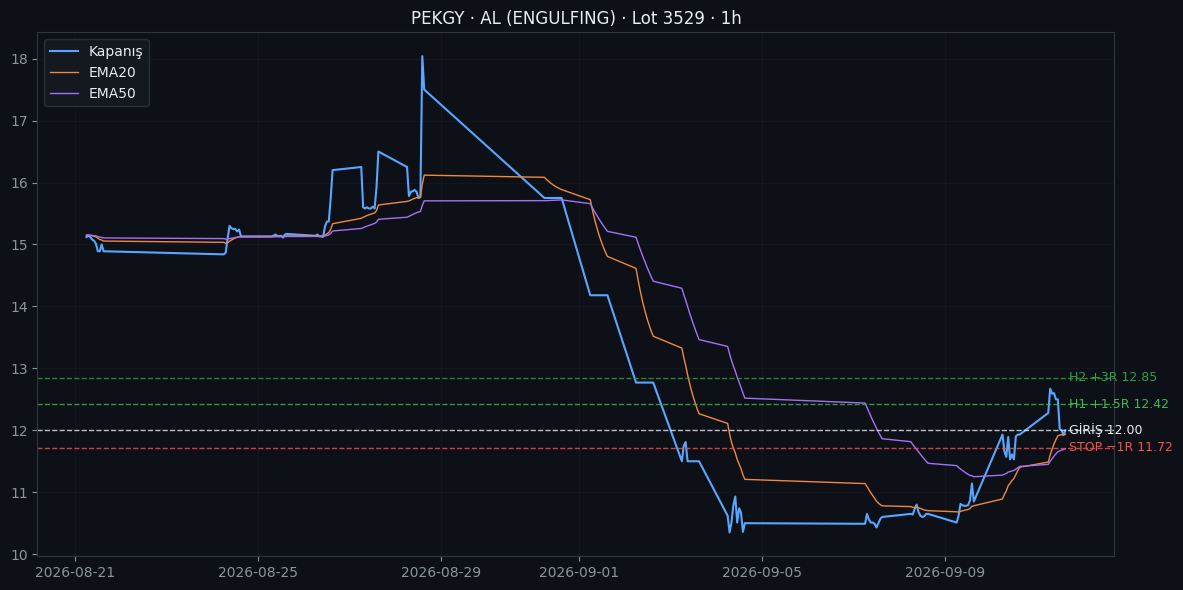

In [11]:
# === HÜCRE 12: AÇIKLAMALI GRAFİK (giriş/stop/hedef) ===
def grafik(row,bar=160):
    df=row["_df"].tail(bar); c=df["close"]
    e20=ema(row["_df"]["close"],20).tail(bar); e50=ema(row["_df"]["close"],50).tail(bar)
    fig,ax=plt.subplots(figsize=(12,6))
    ax.plot(c.index,c,color="#58a6ff",lw=1.5,label="Kapanış")
    ax.plot(e20.index,e20,color="#f0883e",lw=1,label="EMA20"); ax.plot(e50.index,e50,color="#a371f7",lw=1,label="EMA50")
    for sev,rk,et in [(row["Giriş"],"#e6edf3","GİRİŞ"),(row["Stop"],"#f85149","STOP −1R"),
                      (row["Hedef1"],"#3fb950","H1 +1.5R"),(row["Hedef2"],"#2ea043","H2 +3R")]:
        ax.axhline(sev,color=rk,ls="--",lw=1,alpha=.8); ax.text(c.index[-1],sev,f" {et} {sev:.2f}",color=rk,va="center",fontsize=9)
    ax.set_title(f"{row['Hisse']} · {row['Karar']} ({row['Sinyaller']}) · Lot {row['Lot']} · {INTERVAL_STR}",color="#e6edf3")
    ax.legend(facecolor="#161b22",edgecolor="#30363d",labelcolor="#e6edf3",loc="upper left"); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()
if not sonuc.empty:
    for _,row in sonuc.head(5).iterrows(): grafik(row)

In [12]:
# === HÜCRE 13: İŞLEM DEFTERİNİ DEĞERLENDİR (canlı R — backtest'le kıyas) ===
# Çıkış Hücre 6'daki simule_cikis ile birebir aynı — canlı & backtest tutarlı.
def defteri_degerlendir():
    if not os.path.exists(DEFTER): print("Defter yok."); return
    d=pd.read_csv(DEFTER); acik=d[d["R_sonuc"].isna()]
    if acik.empty: print("Açık kayıt yok."); return
    for idx,row in acik.iterrows():
        df=bar_getir(row["Hisse"])
        if df is None: continue
        ts=pd.Timestamp(row["tarama_zamani"])
        ile=df[df.index>ts]
        if len(ile)<1: continue
        sonuc,rr,_=simule_cikis(ile["high"].values,ile["low"].values,ile["close"].values,
                                row["Giriş"],row["Stop"],row["Hedef1"],row["Hedef2"],CFG["SURE"])
        d.loc[idx,"sonuc"]=sonuc; d.loc[idx,"R_sonuc"]=round(rr,3) if rr==rr else np.nan
    d.to_csv(DEFTER,index=False)
    k=d[d["R_sonuc"].notna()]
    if len(k):
        print(f"Kapanan: {len(k)} · ort {k['R_sonuc'].mean():+.3f}R · win %{(k['R_sonuc']>0).mean()*100:.0f}")
        for kr in ["GÜÇLÜ AL","AL"]:
            kk=k[k["Karar"]==kr]
            if len(kk): print(f"  {kr}: {len(kk)} işlem · ort {kk['R_sonuc'].mean():+.3f}R")
        print("(Karşılaştır: Hücre 9 gün içi backtest sonuçların ile — canlı ondan sapmamalı.)")
    return d
print("Birkaç bar/gün sonra çalıştır:  defter = defteri_degerlendir()")

Birkaç bar/gün sonra çalıştır:  defter = defteri_degerlendir()


## 📖 Gün içi nasıl çalışmalıyım

### Canlı sinyal mantığı (1h doğrulamasına göre)
- **AL** = ENGULFING (EMA20 üstünde boğa engulfing mumu) — gün içindeki tek sağlam edge.
- **GÜÇLÜ AL** = ENGULFING **+** ICHIMOKU teyidi — öncelikli, önce bunları doldur.
- DERIN_DEGER/BANKER/CMI karardan çıkarıldı. `Uyarı` sütununda "⚠düşen-bıçak" görürsen o hisse
  teknik olarak dövülmüş bölgede — gün içinde riskli, istersen atla (veya `DERIN_VETO=True`).

### Ritim (zaman dilimine göre)
1. **Her yeni bar kapanışında** (1h'te saat başı) Hücre 1→7'yi çalıştır → gün içi AL listesi.
   Sinyal **kapanan bar** üzerinde üretilir; girişi **bir sonraki bar açılışında** yap (look-ahead yok).
2. Emir kurarken **STOP + HEDEF**'i hemen gir. Önce **GÜÇLÜ AL (ENG+ICHI) > AL** doldur.
3. Hücre 11 defteri güncelle; birkaç bar sonra Hücre 13 ile canlı R'yi ölç.

### Pozisyon yönetimi (backtest bracket'i — DEĞİŞTİRME)
- **Lot** = %1 riske göre; listedekini kullan.
- **HEDEF1 (+1.5R):** yarı sat + stop'u girişe (başabaş) çek → risksiz koşu.
- **HEDEF2 (+3R):** kalanı sat.  · **STOP (−1R):** değerse çık, tartışma yok.
- **SURE = 10 bar:** dolduysa kapanışta çık. (1h'te ≈ 1.25 işlem günü; 15m'de ≈ 2.5 saat.)

### Gün içine özgü uyarılar
- **Zaman dilimini değiştirdiysen** (5m/15m/2h) **Hücre 9'u MUTLAKA yeniden çalıştır** — edge her
  zaman diliminde aynı değil. Canlı mantık ENGULFING'e dayanıyor; başka bir TF'de ENGULFING'in
  `excess_R>0 & t≳2` kaldığını doğrulamadan işleme sokma.
- **Likidite kritik.** Gün içinde ince hacimli hisselerde kayma stopu yer.
- **`ort_R` değil `excess_R`.** Rastgele giriş bile +0.15R veriyor (TL enflasyon sürüklenmesi);
  gerçek edge rastgeleye göre fazlalıktır.
- **SURE'yi gün sanma tuzağı:** `SURE=10` gün değil **bar**. Gerçek süreyi Hücre 2 çıktısı yazıyor.
- **Aynı bar'da çok sinyal.** ENGULFING sık tetiklenir; liste konviksiyon+likiditeye göre sıralanıp
  ilk `MAX_AL` alınır. Sermayeni GÜÇLÜ AL'lara öncelik vererek dağıt.

### Değişmeyen ilkeler
- Elenen kuralları (kırılım/momentum/MACD…) geri ekleme. yfinance kullanma. Sinyal yoksa işlem uydurma.
- Edge küçük; **50-100 işlemde** ortaya çıkar. Tek partiden karar verme, disiplini koru.
- **DERIN_DEGER'i standalone giriş için geri ekleme** — 1h'te istatistiksel olarak zararlı.

> **Yatırım tavsiyesi değildir.** Karar ve risk kullanıcıya aittir.